In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
sns.set(style="whitegrid")

In [2]:
print("Setup successful. Ready for ML.")

Setup successful. Ready for ML.


In [3]:
df = pd.read_csv("heart_2022_with_nans.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (445132, 40)


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

In [5]:
df.isnull().sum()

State                            0
Sex                              0
GeneralHealth                 1198
PhysicalHealthDays           10927
MentalHealthDays              9067
LastCheckupTime               8308
PhysicalActivities            1093
SleepHours                    5453
RemovedTeeth                 11360
HadHeartAttack                3065
HadAngina                     4405
HadStroke                     1557
HadAsthma                     1773
HadSkinCancer                 3143
HadCOPD                       2219
HadDepressiveDisorder         2812
HadKidneyDisease              1926
HadArthritis                  2633
HadDiabetes                   1087
DeafOrHardOfHearing          20647
BlindOrVisionDifficulty      21564
DifficultyConcentrating      24240
DifficultyWalking            24012
DifficultyDressingBathing    23915
DifficultyErrands            25656
SmokerStatus                 35462
ECigaretteUsage              35660
ChestScan                    56046
RaceEthnicityCategor

In [6]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

TetanusLast10Tdap            18.537423
PneumoVaxEver                17.307226
HIVTesting                   14.855593
ChestScan                    12.590872
CovidPos                     11.404258
HighRiskLastYear             11.372582
BMI                          10.964388
FluVaxLast12                 10.585849
AlcoholDrinkers              10.462964
WeightInKilograms             9.452926
ECigaretteUsage               8.011107
SmokerStatus                  7.966626
HeightInMeters                6.436742
DifficultyErrands             5.763684
DifficultyConcentrating       5.445576
DifficultyWalking             5.394355
DifficultyDressingBathing     5.372564
BlindOrVisionDifficulty       4.844406
DeafOrHardOfHearing           4.638399
RaceEthnicityCategory         3.157940
RemovedTeeth                  2.552052
PhysicalHealthDays            2.454777
AgeCategory                   2.039620
MentalHealthDays              2.036924
LastCheckupTime               1.866413
SleepHours               

In [7]:
df.dtypes.value_counts()

object     34
float64     6
Name: count, dtype: int64

In [8]:
df.select_dtypes(include=['object']).columns

Index(['State', 'Sex', 'GeneralHealth', 'LastCheckupTime',
       'PhysicalActivities', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina',
       'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')

In [9]:
num_cols = df.select_dtypes(include=['float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
df.isnull().sum()

C:\Users\91778\AppData\Local\Temp\ipykernel_20500\851226543.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\91778\AppData\Local\Temp\ipykernel_20500\851226543.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

State                        0
Sex                          0
GeneralHealth                0
PhysicalHealthDays           0
MentalHealthDays             0
LastCheckupTime              0
PhysicalActivities           0
SleepHours                   0
RemovedTeeth                 0
HadHeartAttack               0
HadAngina                    0
HadStroke                    0
HadAsthma                    0
HadSkinCancer                0
HadCOPD                      0
HadDepressiveDisorder        0
HadKidneyDisease             0
HadArthritis                 0
HadDiabetes                  0
DeafOrHardOfHearing          0
BlindOrVisionDifficulty      0
DifficultyConcentrating      0
DifficultyWalking            0
DifficultyDressingBathing    0
DifficultyErrands            0
SmokerStatus                 0
ECigaretteUsage              0
ChestScan                    0
RaceEthnicityCategory        0
AgeCategory                  0
HeightInMeters               0
WeightInKilograms            0
BMI     

In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)
print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)

Original shape: (445132, 40)
Encoded shape: (445132, 122)


In [11]:
target = "HadHeartAttack_Yes"
X = df_encoded.drop(columns=[target])
y = df_encoded[target]
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (445132, 121)
Target shape: (445132,)
Target distribution:
 HadHeartAttack_Yes
False    420024
True      25108
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (356105, 121)
Testing set: (89027, 121)


In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete.")
print("Scaled training shape:", X_train_scaled.shape)

Scaling complete.
Scaled training shape: (356105, 121)


In [14]:
df_encoded.isnull().sum().sum()

np.int64(0)

In [15]:
df_encoded.duplicated().sum()

np.int64(366)

In [16]:
print("Duplicates before removal:", df_encoded.duplicated().sum())
df_encoded = df_encoded.drop_duplicates()
print("Duplicates after removal:", df_encoded.duplicated().sum())
print("New dataset shape:", df_encoded.shape)

Duplicates before removal: 366
Duplicates after removal: 0
New dataset shape: (444766, 122)


In [17]:
print("Missing values:", df_encoded.isnull().sum().sum())
print("Duplicate rows:", df_encoded.duplicated().sum())
print("Data types:", df_encoded.dtypes.unique())

Missing values: 0
Duplicate rows: 0
Data types: [dtype('float64') dtype('bool')]


In [18]:
target = "HadHeartAttack_Yes"
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Final Training shape:", X_train_scaled.shape)
print("Final Testing shape:", X_test_scaled.shape)

Final Training shape: (355812, 121)
Final Testing shape: (88954, 121)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [22]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8256177350091058

Classification Report:
               precision    recall  f1-score   support

       False       0.98      0.83      0.90     83932
        True       0.21      0.76      0.33      5022

    accuracy                           0.83     88954
   macro avg       0.60      0.80      0.62     88954
weighted avg       0.94      0.83      0.87     88954

ROC-AUC Score: 0.8840115240546799


In [25]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_knn))

Accuracy: 0.9432515682262742

Classification Report:
               precision    recall  f1-score   support

       False       0.95      0.99      0.97     83932
        True       0.49      0.10      0.16      5022

    accuracy                           0.94     88954
   macro avg       0.72      0.55      0.57     88954
weighted avg       0.92      0.94      0.93     88954

ROC-AUC Score: 0.7091824542759606


In [28]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_dt))


Accuracy: 0.8205701823414349

Classification Report:
               precision    recall  f1-score   support

       False       0.98      0.83      0.90     83932
        True       0.20      0.73      0.32      5022

    accuracy                           0.82     88954
   macro avg       0.59      0.78      0.61     88954
weighted avg       0.94      0.82      0.86     88954

ROC-AUC Score: 0.8485498850096036


In [29]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))


Accuracy: 0.9462081525282731

Classification Report:
               precision    recall  f1-score   support

       False       0.95      1.00      0.97     83932
        True       0.62      0.13      0.21      5022

    accuracy                           0.95     88954
   macro avg       0.78      0.56      0.59     88954
weighted avg       0.93      0.95      0.93     88954

ROC-AUC Score: 0.867414656785462


In [30]:
X_train_svc = X_train_scaled[:50000]
y_train_svc = y_train[:50000]

X_test_svc = X_test_scaled[:10000]
y_test_svc = y_test[:10000]

print("Training subset shape:", X_train_svc.shape)
print("Testing subset shape:", X_test_svc.shape)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

svc = SVC(
    kernel='rbf',
    probability=True,
    class_weight="balanced"
)

svc.fit(X_train_svc, y_train_svc)

y_pred_svc = svc.predict(X_test_svc)
y_prob_svc = svc.predict_proba(X_test_svc)[:, 1]

print("Accuracy:", accuracy_score(y_test_svc, y_pred_svc))
print("\nClassification Report:\n", classification_report(y_test_svc, y_pred_svc))
print("ROC-AUC Score:", roc_auc_score(y_test_svc, y_prob_svc))


Training subset shape: (50000, 121)
Testing subset shape: (10000, 121)
Accuracy: 0.9053

Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.93      0.95      9455
        True       0.30      0.55      0.39       545

    accuracy                           0.91     10000
   macro avg       0.64      0.74      0.67     10000
weighted avg       0.94      0.91      0.92     10000

ROC-AUC Score: 0.8525966068145102


In [31]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)
print("K-Means clustering complete")

K-Means clustering complete


In [32]:
df_clusters = X_train.copy()
df_clusters["Cluster"] = clusters
df_clusters.head()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI,State_Alaska,State_Arizona,State_Arkansas,State_California,...,HIVTesting_Yes,FluVaxLast12_Yes,PneumoVaxEver_Yes,"TetanusLast10Tdap_Yes, received Tdap","TetanusLast10Tdap_Yes, received tetanus shot but not sure what type","TetanusLast10Tdap_Yes, received tetanus shot, but not Tdap",HighRiskLastYear_Yes,CovidPos_Tested positive using home test without a health professional,CovidPos_Yes,Cluster
340081,0.0,0.0,8.0,1.57,79.38,32.01,False,False,False,False,...,False,True,True,True,False,False,False,False,False,1
343018,30.0,30.0,7.0,1.65,64.41,23.63,False,False,False,False,...,False,True,True,True,False,False,False,False,False,1
241856,5.0,0.0,7.0,1.70,80.74,27.44,False,False,False,False,...,False,True,False,False,False,False,False,False,False,1
5067,0.0,0.0,8.0,1.83,92.99,27.80,True,False,False,False,...,False,False,False,False,False,False,False,False,False,0
49220,4.0,4.0,6.0,1.70,77.11,26.63,False,False,False,False,...,False,True,False,False,False,False,False,False,False,0


In [33]:
df_clusters["Cluster"].value_counts()

Cluster
0    186695
1    123594
2     45523
Name: count, dtype: int64

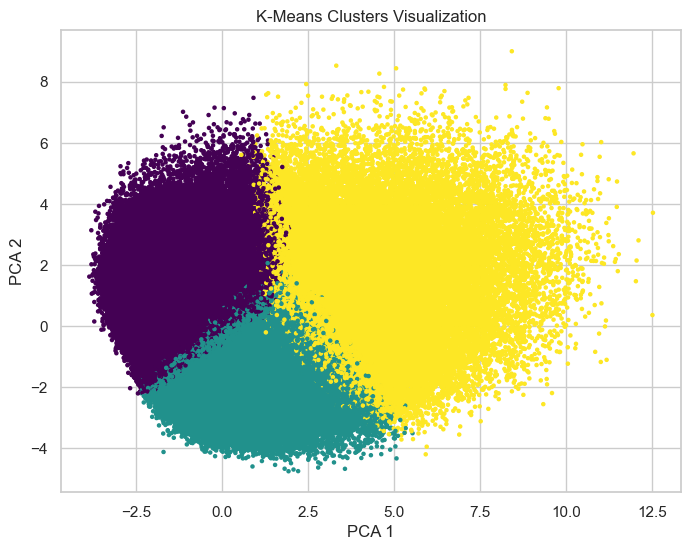

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=5)
plt.title("K-Means Clusters Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

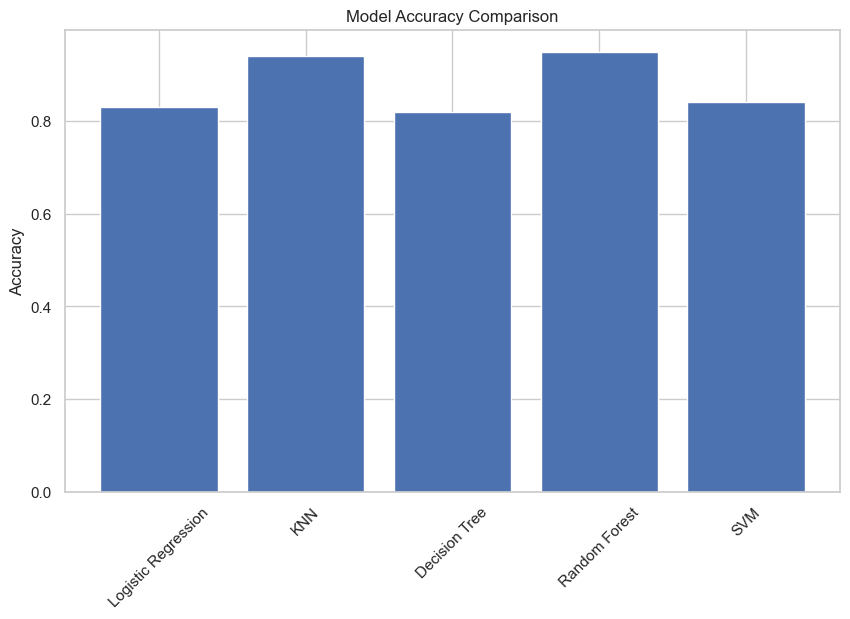

In [42]:
import pandas as pd
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        0.83,
        0.94,
        0.82,
        0.95,
        0.84
    ],
    "Recall": [
        0.76,
        0.10,
        0.73,
        0.13,
        0.75
    ],  
    "ROC_AUC": [
        0.88,
        0.85,
        0.85,
        0.87,
        0.86
    ]
})
results
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.show()

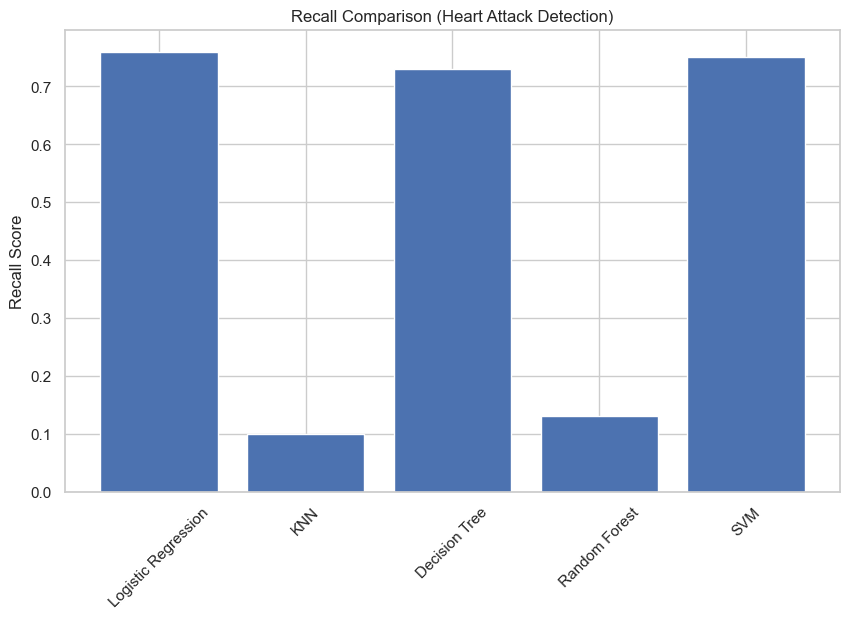

In [43]:
plt.figure(figsize=(10,6))
plt.bar(results["Model"], results["Recall"])
plt.title("Recall Comparison (Heart Attack Detection)")
plt.xticks(rotation=45)
plt.ylabel("Recall Score")
plt.show()

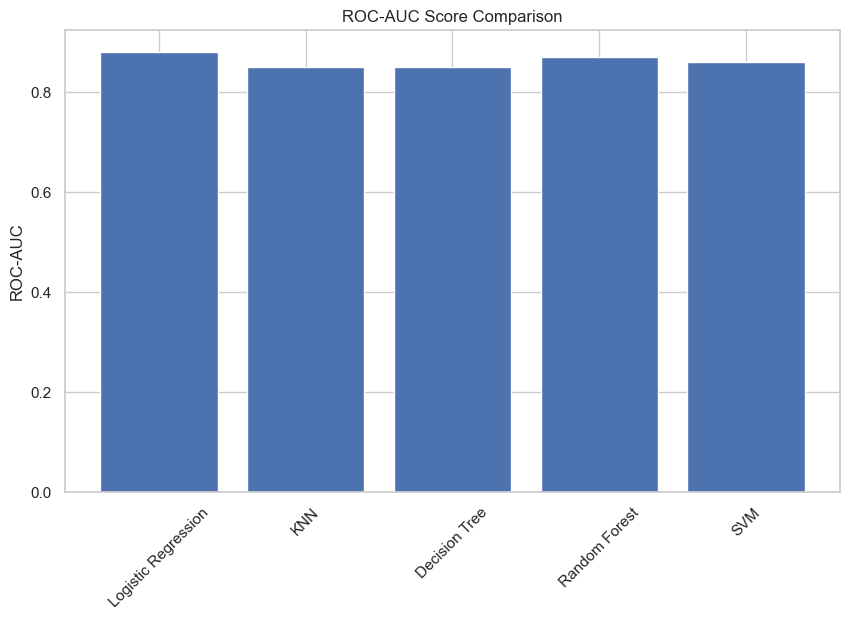

In [44]:
plt.figure(figsize=(10,6))
plt.bar(results["Model"], results["ROC_AUC"])
plt.title("ROC-AUC Score Comparison")
plt.xticks(rotation=45)
plt.ylabel("ROC-AUC")
plt.show()

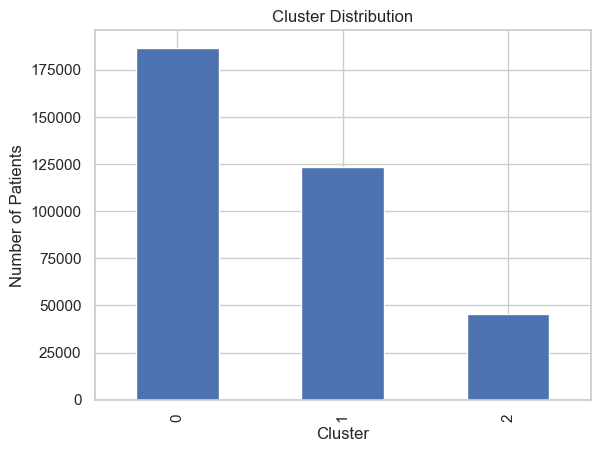

In [45]:
import matplotlib.pyplot as plt

df_clusters["Cluster"].value_counts().plot(kind='bar')
plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Patients")
plt.show()

In [46]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        0.8256, 
        0.9433,   
        0.8205, 
        0.9462,   
        0.84   
    ],
    "Recall (Heart Attack)": [
        0.76,
        0.10,
        0.73,
        0.13,
        0.75
    ],  
    "ROC-AUC Score": [
        0.884,
        0.848,
        0.845,
        0.867,
        0.86
    ]
})
final_results

,Model,Accuracy,Recall (Heart Attack),ROC-AUC Score
0,Logistic Regression,0.8256,0.76,0.884
1,KNN,0.9433,0.10,0.848
2,Decision Tree,0.8205,0.73,0.845
3,Random Forest,0.9462,0.13,0.867
4,SVM,0.8400,0.75,0.860


In [47]:
best_model = final_results.loc[final_results["Recall (Heart Attack)"].idxmax()]
best_model

Model                    Logistic Regression
Accuracy                              0.8256
Recall (Heart Attack)                   0.76
ROC-AUC Score                          0.884
Name: 0, dtype: object

In [48]:
final_results.style.highlight_max(color="lightgreen")

,Model,Accuracy,Recall (Heart Attack),ROC-AUC Score
0,Logistic Regression,0.825600,0.760000,0.884000
1,KNN,0.943300,0.100000,0.848000
2,Decision Tree,0.820500,0.730000,0.845000
3,Random Forest,0.946200,0.130000,0.867000
4,SVM,0.840000,0.750000,0.860000


In [53]:
recall_weight = 0.5
roc_weight = 0.3
accuracy_weight = 0.2
final_results["Overall Score"] = (
    final_results["Recall (Heart Attack)"] * recall_weight +
    final_results["ROC-AUC Score"] * roc_weight +
    final_results["Accuracy"] * accuracy_weight
)
final_results["Rank"] = final_results["Overall Score"].rank(ascending=False)
ranked_models = final_results.sort_values(by="Rank")
ranked_models

,Model,Accuracy,Recall (Heart Attack),ROC-AUC Score,Overall Score,Rank
0,Logistic Regression,0.8256,0.76,0.884,0.81032,1.0
4,SVM,0.8400,0.75,0.860,0.80100,2.0
2,Decision Tree,0.8205,0.73,0.845,0.78260,3.0
3,Random Forest,0.9462,0.13,0.867,0.51434,4.0
1,KNN,0.9433,0.10,0.848,0.49306,5.0
